In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

calculated = pd.read_csv(
    "../data/processed/dtd_output.csv"
)

provided = pd.read_csv(
    "../data/raw/full_historical_dtd_output.csv"
)

calculated["Date"] = pd.to_datetime(
    calculated["Date"]
)
provided["REAL_DTD_DATE"] = pd.to_datetime(
    provided["REAL_DTD_DATE"].astype(str),
    format="%Y%m%d"
)
display(calculated.head())
display(provided.head())

,Comp_no,Date,CUR_MKT_CAP(HKD),BS_CUR_LIAB(HKD),BS_LT_BORROW(HKD),BS_TOT_LIAB2(HKD),BS_TOT_ASSET(HKD),Risk_Free_Rate,COMPANY_ID,parameter_date,sigma,delta,parameter_carried_forward,default_threshold,asset_value,DTD,calculation_status,error_message
0,23286,2024-01-02,19698.95,347664.860802,120637.759408,472854.958791,586180.702774,3.98,23286,2024-01-02,0.054030,0.521872,False,410359.477921,411342.515426,0.044285,success,NaN
1,23286,2024-01-03,19952.15,347664.860802,120637.759408,472854.958791,586180.702774,3.97,23286,2024-01-03,0.053324,0.521872,False,410359.477921,411803.815788,0.065890,success,NaN
2,23286,2024-01-04,19977.47,347664.860802,120637.759408,472854.958791,586180.702774,3.97,23286,2024-01-04,0.053354,0.521872,False,410359.477921,411831.218723,0.067100,success,NaN
3,23286,2024-01-05,20104.07,347664.860802,120637.759408,472854.958791,586180.702774,4.00,23286,2024-01-05,0.053249,0.521872,False,410359.477921,411888.442578,0.069842,success,NaN
4,23286,2024-01-08,19648.31,347664.860802,120637.759408,472854.958791,586180.702774,4.02,23286,2024-01-08,0.053236,0.521872,False,410359.477921,411241.992834,0.040354,success,NaN


,COMPANY_ID,REAL_DTD_DATE,DTD_VALUE
0,23286,2024-01-02,0.044285
1,23286,2024-01-03,0.065890
2,23286,2024-01-04,0.067100
3,23286,2024-01-05,0.069842
4,23286,2024-01-08,0.040354


In [2]:
# keep successful calculation
calculated_success = calculated[
    calculated["calculation_status"] == "success"
].copy()

print(
    "Successful calculations:",
    len(calculated_success)
)

print(
    "Failed calculations:",
    len(calculated) - len(calculated_success)
)

Successful calculations: 677
Failed calculations: 0


In [3]:
# inspect failure
display(
    calculated[
        calculated["calculation_status"] != "success"
    ][
        [
            "Comp_no",
            "Date",
            "calculation_status",
            "error_message"
        ]
    ]
)

,Comp_no,Date,calculation_status,error_message


In [4]:
# merge with CRI output
comparison = calculated_success.merge(
    provided[
        [
            "COMPANY_ID",
            "REAL_DTD_DATE",
            "DTD_VALUE"
        ]
    ],
    left_on=[
        "COMPANY_ID",
        "Date"
    ],
    right_on=[
        "COMPANY_ID",
        "REAL_DTD_DATE"
    ],
    how="outer"
)
comparison = comparison.rename(
    columns={
        "DTD": "CALCULATED_DTD",
        "DTD_VALUE": "PROVIDED_DTD"
    }
)

# calculate difference
comparison["DIFFERENCE"] = (
    comparison["CALCULATED_DTD"]
    - comparison["PROVIDED_DTD"]
)

comparison["ABS_DIFFERENCE"] = (
    comparison["DIFFERENCE"].abs()
)
display(
    comparison[
        [
            "COMPANY_ID",
            "Date",
            "CALCULATED_DTD",
            "PROVIDED_DTD",
            "DIFFERENCE",
            "ABS_DIFFERENCE"
        ]
    ]
)
comparison[
        [
            "COMPANY_ID",
            "Date",
            "CALCULATED_DTD",
            "PROVIDED_DTD",
            "DIFFERENCE",
            "ABS_DIFFERENCE"
        ]
    ].to_csv('../data/processed/comparison.csv', index=False)

,COMPANY_ID,Date,CALCULATED_DTD,PROVIDED_DTD,DIFFERENCE,ABS_DIFFERENCE
0,23286,2024-01-02,0.044285,0.044285,-1.262135e-08,1.262135e-08
1,23286,2024-01-03,0.065890,0.065890,-1.980824e-09,1.980824e-09
2,23286,2024-01-04,0.067100,0.067100,-1.768018e-09,1.768018e-09
3,23286,2024-01-05,0.069842,0.069842,-1.133483e-09,1.133483e-09
4,23286,2024-01-08,0.040354,0.040354,-1.252280e-08,1.252280e-08
...,...,...,...,...,...,...
672,23286,2026-09-25,0.380399,NaN,NaN,NaN
673,23286,2026-09-28,0.452514,NaN,NaN,NaN
674,23286,2026-09-29,0.622230,NaN,NaN,NaN
675,23286,2026-09-30,0.601156,NaN,NaN,NaN


In [7]:
# find largest discrepancy
largest_diff = (
    comparison
    .sort_values(
        "ABS_DIFFERENCE",
        ascending=False
    )
    [
        [
            "Date",
            "CALCULATED_DTD",
            "PROVIDED_DTD",
            "DIFFERENCE",
            "CUR_MKT_CAP(HKD)",
            "Risk_Free_Rate",
            "sigma",
            "delta",
            "default_threshold",
            "asset_value",
            "parameter_carried_forward"
        ]
    ]
    .head(20)
)

display(largest_diff)

,Date,CALCULATED_DTD,PROVIDED_DTD,DIFFERENCE,CUR_MKT_CAP(HKD),Risk_Free_Rate,sigma,delta,default_threshold,asset_value,parameter_carried_forward
583,2026-05-20,1.163773,1.176370,-0.012598,24862.671078,2.57,0.043023,0.487847,321216.626891,337709.147977,False
506,2026-01-22,0.725616,0.731081,-0.005466,24507.126390,2.21,0.055054,0.487847,370057.328788,385139.511550,False
579,2026-05-14,1.362646,1.360003,0.002643,27427.666336,2.54,0.042688,0.487847,321216.626891,340455.689020,False
577,2026-05-12,1.394299,1.391662,0.002637,27783.208603,2.42,0.043252,0.487847,321216.626891,341183.906367,False
576,2026-05-11,1.399664,1.397030,0.002634,27910.189022,2.40,0.043480,0.487847,321216.626891,341372.048395,False
575,2026-05-08,1.373855,1.371233,0.002622,27808.605171,2.47,0.043602,0.487847,321216.626891,341046.587010,False
578,2026-05-13,1.345842,1.343223,0.002619,27529.250187,2.56,0.043286,0.487847,321216.626891,340485.379268,False
580,2026-05-15,1.298796,1.296226,0.002570,26513.409258,2.53,0.042730,0.487847,321216.626891,339547.500757,False
574,2026-05-07,1.279182,1.276661,0.002521,26284.847410,2.46,0.043315,0.487847,321216.626891,339516.984018,False
573,2026-05-06,1.253857,1.251364,0.002493,25954.699290,2.46,0.043385,0.487847,321216.626891,339174.273591,False


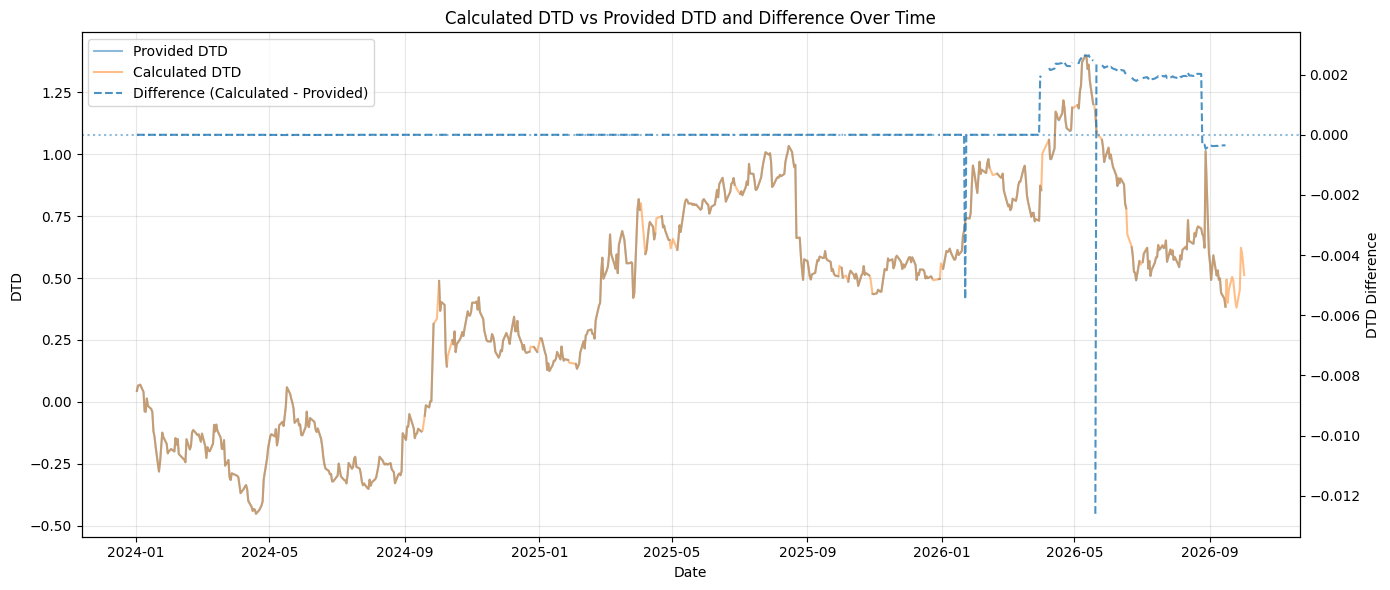

In [6]:
# plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# =========================
# Left axis: DTD values
# =========================

ax1.plot(
    comparison["Date"],
    comparison["PROVIDED_DTD"],
    label="Provided DTD",
    alpha=0.5
)

ax1.plot(
    comparison["Date"],
    comparison["CALCULATED_DTD"],
    label="Calculated DTD",
    alpha=0.5
)

ax1.set_xlabel("Date")
ax1.set_ylabel("DTD")
ax1.grid(alpha=0.3)


# =========================
# Right axis: Difference
# =========================

ax2 = ax1.twinx()

ax2.plot(
    comparison["Date"],
    comparison["DIFFERENCE"],
    label="Difference (Calculated - Provided)",
    linestyle="--",
    alpha=0.8
)

ax2.axhline(
    y=0,
    linestyle=":",
    alpha=0.5
)

ax2.set_ylabel("DTD Difference")


# =========================
# Combined legend
# =========================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.title(
    "Calculated DTD vs Provided DTD and Difference Over Time"
)

plt.tight_layout()
plt.show()

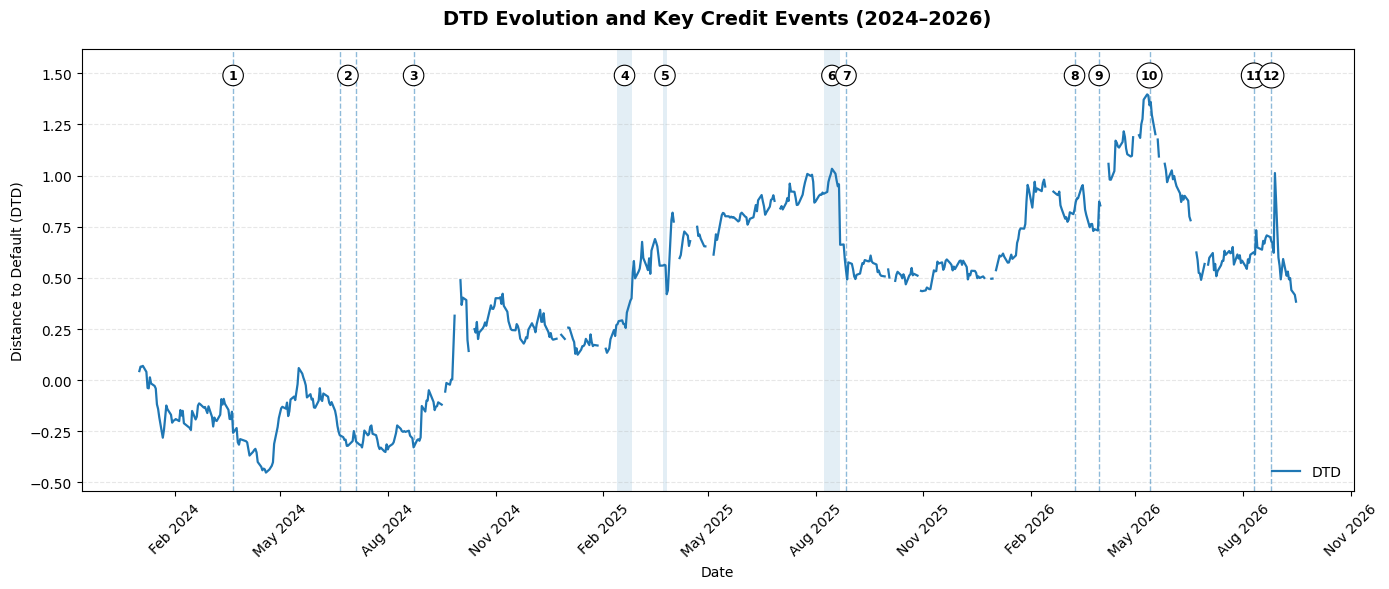

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. Load DTD data
# ============================================================

df = pd.read_csv(
    "../data/raw/full_historical_dtd_output.csv"
)

# REAL_DTD_DATE is stored as YYYYMMDD
df["REAL_DTD_DATE"] = pd.to_datetime(
    df["REAL_DTD_DATE"].astype(str),
    format="%Y%m%d"
)

df = df.sort_values("REAL_DTD_DATE")


# ============================================================
# 2. Define events
# ============================================================

events = [
    {
        "id": 1,
        "start": "2024-03-22",
        "end": "2024-03-22",
    },
    {
        "id": 2,
        "dates": [
            "2024-06-21",
            "2024-07-05",
        ],
    },
    {
        "id": 3,
        "start": "2024-08-23",
        "end": "2024-08-23",
    },
    {
        "id": 4,
        "start": "2025-02-13",
        "end": "2025-02-25",
    },
    {
        "id": 5,
        "start": "2025-03-24",
        "end": "2025-03-27",
    },
    {
        "id": 6,
        "start": "2025-08-08",
        "end": "2025-08-22",
    },
    {
        "id": 7,
        "start": "2025-08-27",
        "end": "2025-08-27",
    },
    {
        "id": 8,
        "start": "2026-03-10",
        "end": "2026-03-10",
    },
    {
        "id": 9,
        "start": "2026-03-31",
        "end": "2026-03-31",
    },
    {
        "id": 10,
        "start": "2026-05-13",
        "end": "2026-05-13",
    },
    {
        "id": 11,
        "start": "2026-08-10",
        "end": "2026-08-10",
    },
    {
        "id": 12,
        "start": "2026-08-25",
        "end": "2026-08-25",
    },
]


# ============================================================
# 3. Plot DTD
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    df["REAL_DTD_DATE"],
    df["DTD_VALUE"],
    linewidth=1.6,
    label="DTD",
)


# ============================================================
# 4. Add event markers
# ============================================================

y_min = df["DTD_VALUE"].min()
y_max = df["DTD_VALUE"].max()

y_range = y_max - y_min

# Position event numbers above the DTD series
label_y = y_max + y_range * 0.05


for event in events:

    event_id = event["id"]

    # --------------------------------------------------------
    # Event with multiple separate dates
    # --------------------------------------------------------

    if "dates" in event:

        event_dates = [
            pd.Timestamp(date)
            for date in event["dates"]
        ]

        for date in event_dates:

            ax.axvline(
                date,
                linestyle="--",
                linewidth=1,
                alpha=0.5,
            )

        # Put one event number between the two dates
        label_date = (
            event_dates[0]
            + (event_dates[1] - event_dates[0]) / 2
        )

    else:

        start = pd.Timestamp(event["start"])
        end = pd.Timestamp(event["end"])

        # ----------------------------------------------------
        # Single-date event
        # ----------------------------------------------------

        if start == end:

            ax.axvline(
                start,
                linestyle="--",
                linewidth=1,
                alpha=0.5,
            )

            label_date = start

        # ----------------------------------------------------
        # Event occurring over a period
        # ----------------------------------------------------

        else:

            ax.axvspan(
                start,
                end,
                alpha=0.12,
            )

            label_date = (
                start
                + (end - start) / 2
            )

    # --------------------------------------------------------
    # Event number
    # --------------------------------------------------------

    ax.text(
        label_date,
        label_y,
        str(event_id),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8,
        ),
    )


# ============================================================
# 5. Formatting
# ============================================================

ax.set_title(
    "DTD Evolution and Key Credit Events (2024–2026)",
    fontsize=14,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel("Date")
ax.set_ylabel("Distance to Default (DTD)")


# Show date labels every 3 months
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45)


# Horizontal grid only
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)


# Leave space above DTD series for event numbers
ax.set_ylim(
    y_min - y_range * 0.05,
    y_max + y_range * 0.12,
)


ax.legend(
    frameon=False,
    loc="lower right",
)


plt.tight_layout()
plt.show()